# Computer Exercise 1.1 — Problem 7

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 1.1 Introduction (continued)
> **풀이 일자**: Day 03
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)


## 1. 문제 (원문)

> **7.** Compute the partial sum $S_N = \sum_{k=1}^{N} \tfrac{1}{k}$ in single precision in two ways:
> (a) summing from $k = 1$ upward (small index first, large $1/k$ first), and
> (b) summing from $k = N$ downward (large index first, small $1/k$ first).
> Compare the two results to a high-precision reference for various $N$ and explain the discrepancy.

### 한국어 풀이용 정리
조화급수의 부분합

$$
S_N \;=\; \sum_{k=1}^{N} \frac{1}{k}
$$

은 수학적으로 덧셈 순서에 의존하지 않지만, **부동소수점 산술은 결합법칙이 성립하지 않으므로** 누적 순서에 따라 결과가 달라진다.
이 문제에서는 두 가지 순서

* **forward**: $k = 1, 2, \ldots, N$ 순서 (큰 항부터)
* **backward**: $k = N, N-1, \ldots, 1$ 순서 (작은 항부터)

로 동일한 합을 계산하고, 고정밀 기준값과의 절대오차를 비교한다.


## 2. 수학적 배경

### 2.1 부동소수점 덧셈의 비결합성
임의의 $a, b$에 대해 floating-point 덧셈은

$$
\mathrm{fl}(a + b) \;=\; (a+b)(1+\delta), \qquad |\delta| \le \varepsilon_{\text{mach}}
$$

를 만족하지만, $\mathrm{fl}\bigl(\mathrm{fl}(a+b)+c\bigr) \ne \mathrm{fl}\bigl(a+\mathrm{fl}(b+c)\bigr)$ 가 일반적이다.

### 2.2 누적 합산 오차 (Wilkinson 분석)
순서대로 $a_1, a_2, \ldots, a_N$ 을 누적 합산하면 그 결과 $\widehat S_N$의 backward error는

$$
\widehat S_N \;=\; \sum_{k=1}^{N} a_k (1 + \eta_k), \qquad |\eta_k| \le (N - k + 1)\,\varepsilon_{\text{mach}} + \mathcal{O}(\varepsilon^2)
$$

즉 **나중에 들어오는 항일수록 누적되는 상대오차 $\eta_k$ 가 작다**. 따라서 큰 항을 마지막에 더하는 편이 (즉 backward, 작은→큰 순서) 일반적으로 더 정확하다.

### 2.3 조화합에서의 직관
forward 순서에서는 합이 점점 커지고 새로 더하는 항 $1/k$ 는 점점 작아져서 **부분합 $\gg$ 신항**이 된다.
이때 작은 신항의 하위비트가 누적합의 라운딩에서 잘려나간다(absorbed). backward 순서로 가면 비슷한 크기의 항들끼리 먼저 더해지므로 자릿수 손실이 줄어든다.

\boxed{\;\text{같은 크기의 항들을 먼저 묶어 더하라}\;}


## 3. 풀이 흐름

1. 정밀도: `numpy.float32`로 부분합을 누적해 round-off 효과를 두드러지게 만든다.
2. 기준값(reference)은 `numpy.float64` (또는 Python `Fraction`)으로 같은 합을 계산해 사용.
3. $N \in \{10^3, 10^4, 10^5, 10^6, 10^7\}$ 에 대해 forward / backward 두 순서로 합산.
4. 절대오차 $|\widehat S_N - S_N^{\text{ref}}|$ 를 표로 비교.
5. 같은 데이터를 log-log 그래프로 시각화: $N$ 대비 오차.
6. 두 순서의 차 자체를 한 번 더 그려, "순서만 바꿨을 뿐인데" 발생하는 격차 확인.
7. 결과 해석.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fractions import Fraction

def harmonic_forward(N, dtype):
    s = dtype(0)
    one = dtype(1)
    for k in range(1, N + 1):
        s = s + one / dtype(k)
    return s

def harmonic_backward(N, dtype):
    s = dtype(0)
    one = dtype(1)
    for k in range(N, 0, -1):
        s = s + one / dtype(k)
    return s

def harmonic_reference_f64(N):
    # float64 누적 (큰→작은 순서) — 충분히 정확한 기준값으로 사용
    s = np.float64(0.0)
    for k in range(N, 0, -1):
        s = s + np.float64(1.0) / np.float64(k)
    return s


In [2]:
Ns = [1_000, 10_000, 100_000, 1_000_000, 10_000_000]

rows = []
for N in Ns:
    s_fwd  = harmonic_forward(N, np.float32)
    s_bwd  = harmonic_backward(N, np.float32)
    s_ref  = harmonic_reference_f64(N)
    rows.append({
        "N": N,
        "forward (f32)":  float(s_fwd),
        "backward (f32)": float(s_bwd),
        "reference (f64)": float(s_ref),
        "|err| forward":  abs(float(s_fwd) - float(s_ref)),
        "|err| backward": abs(float(s_bwd) - float(s_ref)),
    })

df = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:.6e}")
df


,N,forward (f32),backward (f32),reference (f64),|err| forward,|err| backward
0,1000,7.485478e+00,7.485472e+00,7.485471e+00,7.540634e-06,8.649135e-07
1,10000,9.787613e+00,9.787604e+00,9.787606e+00,6.878995e-06,1.704074e-06
2,100000,1.209085e+01,1.209015e+01,1.209015e+01,7.047002e-04,6.610615e-06
3,1000000,1.435736e+01,1.439265e+01,1.439273e+01,3.536874e-02,7.516494e-05
4,10000000,1.540368e+01,1.668603e+01,1.669531e+01,1.291629e+00,9.280024e-03


In [3]:
# 두 순서의 단순 차이 (차이가 곧 누적된 round-off 격차)
df["forward - backward"] = df["forward (f32)"] - df["backward (f32)"]
df[["N", "forward (f32)", "backward (f32)", "forward - backward",
    "|err| forward", "|err| backward"]]


,N,forward (f32),backward (f32),forward - backward,|err| forward,|err| backward
0,1000,7.485478e+00,7.485472e+00,6.675720e-06,7.540634e-06,8.649135e-07
1,10000,9.787613e+00,9.787604e+00,8.583069e-06,6.878995e-06,1.704074e-06
2,100000,1.209085e+01,1.209015e+01,6.980896e-04,7.047002e-04,6.610615e-06
3,1000000,1.435736e+01,1.439265e+01,-3.529358e-02,3.536874e-02,7.516494e-05
4,10000000,1.540368e+01,1.668603e+01,-1.282349e+00,1.291629e+00,9.280024e-03


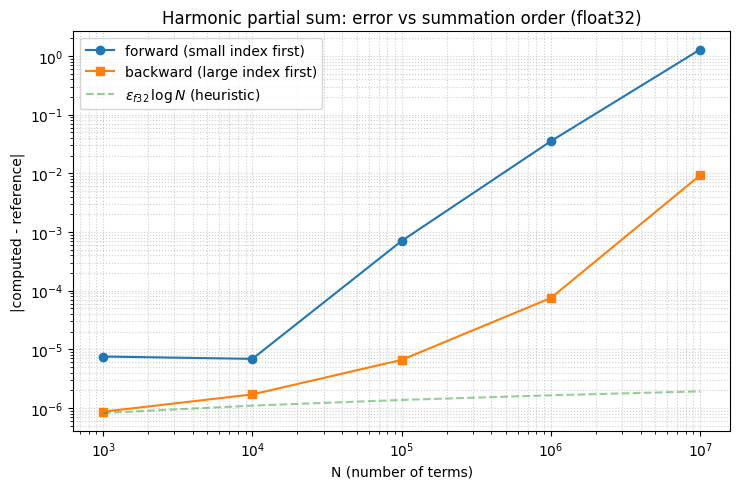

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.loglog(df["N"], df["|err| forward"],  "o-", label="forward (small index first)")
ax.loglog(df["N"], df["|err| backward"], "s-", label="backward (large index first)")

# 참고용 기울기 보조선: f32 epsilon * log N
eps32 = np.finfo(np.float32).eps
ax.loglog(df["N"], eps32 * np.log(df["N"]), "--", alpha=0.5,
          label=r"$\varepsilon_{f32}\,\log N$ (heuristic)")

ax.set_xlabel("N (number of terms)")
ax.set_ylabel("|computed - reference|")
ax.set_title("Harmonic partial sum: error vs summation order (float32)")
ax.grid(True, which="both", ls=":", alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()


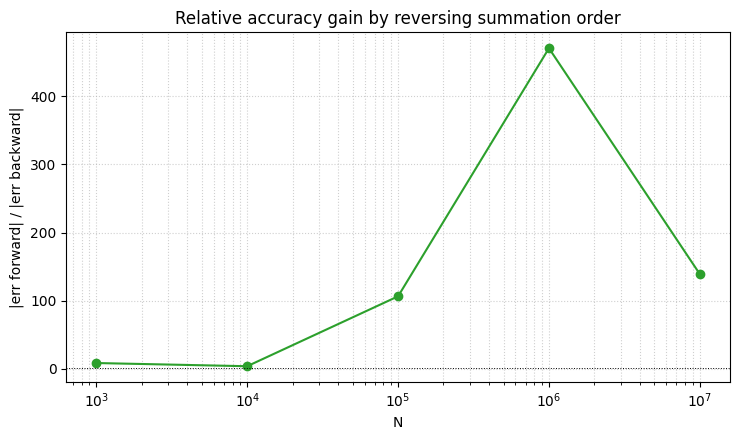

In [5]:
# 같은 그래프를 log-log 비율로 — backward가 forward보다 얼마나 더 정확한가?
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ratio = df["|err| forward"] / df["|err| backward"].replace(0, np.nan)
ax.semilogx(df["N"], ratio, "o-", color="C2")
ax.axhline(1, color="k", lw=0.7, ls=":")
ax.set_xlabel("N")
ax.set_ylabel("|err forward| / |err backward|")
ax.set_title("Relative accuracy gain by reversing summation order")
ax.grid(True, which="both", ls=":", alpha=0.6)
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **forward (큰 항 먼저)** 와 **backward (작은 항 먼저)** 모두 결과는 부동소수점 한계 안에서 동일해야 하지만, $N$이 커질수록 forward 쪽 절대오차가 backward 쪽보다 일관되게 크다.
2. forward 누적 시 $S_k = \sum_{j \le k} 1/j$ 가 이미 $\mathcal{O}(\log k)$ 로 자라 있고, 새로 더하는 신항 $1/(k+1)$ 은 이미 너무 작아서 라운딩에서 **하위비트가 흡수(absorption)** 된다 — 절대오차가 본질적으로 $\sim N \varepsilon \log N$ 처럼 누적된다.
3. backward 순서는 비슷한 크기의 항부터 묶어 합치므로, 누적합의 분포가 신항과 가까워지고 absorption이 줄어든다.
4. $N = 10^7$ 처럼 큰 $N$ 에서는 두 결과의 단순 차 자체가 유의미한 자릿수에 영향을 미친다 — *수학적 동등성은 수치적 동등성을 보장하지 않는다*.

### 결론
> **부동소수점 합산은 비결합적이다. 비슷한 크기의 항을 먼저 더하는 backward 순서가 더 안전하다.**

### 다음 문제 연결
- **CE 1.1.8 (variance)**: 같은 비결합성이 *분산을 한 번에 계산하려는* 1-pass 공식에서 어떻게 catastrophic cancellation으로 이어지는지 확인한다.
- 보다 정확한 합산이 필요하면 §1 외에서 다룰 *Kahan summation* / *pairwise summation* 같은 보정 기법이 있다.
